<a href="https://colab.research.google.com/github/CRAFTYPROGRAMMER826/Lead_Conversion_Prediction/blob/main/LEADS_XGboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install faker
# installing faker library to create a new dataset
import pandas as pd
import numpy as np
import random
from faker import Faker

# Initialize Faker
fake = Faker()

# Set random seed
random.seed(42)
np.random.seed(42) # configuring the random seed=42  to create the exact same random data for every time the code runs

# Constants
num_entries = 500
lead_sources = ['Website', 'Referral', 'Ad Campaign', 'Cold Call', 'Event', 'Email'] # generating the random data for leads with params like
interest_levels = list(range(1, 11))  # 1 to 10
follow_up_counts = list(range(0, 11))  # 0 to 10

# Generate Data
data = {
    'name': [fake.name() for _ in range(num_entries)],
    'budget': np.random.randint(5000, 100001, num_entries),    #generating the columns for categoical and numerical
    #variables along with the values corresponding to them for each customer
    'interest_level': np.random.choice(interest_levels, num_entries),
    'lead_source': np.random.choice(lead_sources, num_entries),
    'follow_up_count': np.random.choice(follow_up_counts, num_entries),
    'converted': np.random.choice([0, 1], num_entries, p=[0.7, 0.3])
}

# Create DataFrame
df = pd.DataFrame(data)
df.head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 66.4 MB/s eta 0:00:00


,name,budget,interest_level,lead_source,follow_up_count,converted
0,Kelly Oneill,20795,8,Website,7,0
1,Linda Guerra,5860,5,Website,3,0
2,Jill Williams,81820,4,Website,10,0
3,Kim Young,59886,8,Referral,9,1
4,Kirk Fritz,11265,7,Email,4,0


In [ ]:
(df.to_csv("leads_dataset.csv", index=False))# exporting the data to a csv file



In [ ]:
X = df[['budget', 'interest_level', 'follow_up_count', 'lead_source']]  # while we want to assign weights to each type of lead source based on the pattern
#discovered from dataset it won't be possible if the lead sources are present in as to measure the rate of success or failure for each lead source the
# lead source needs to be an independent variable on x axis and currently it is represented as a dependent variable on y axis so conversion is necessary
y = df['converted']  # target label


In [ ]:
# Select features
X = df[['budget', 'interest_level', 'follow_up_count', 'lead_source']]

# One-hot encode the 'lead_source' column
X_encoded = pd.get_dummies(X, columns=['lead_source'], drop_first=False)
#we convert the shape of the dataframe by using the pd.getdummies() function and create the seperate columns for each lead source value
# Preview transformed DataFrame
X_encoded.head()


,budget,interest_level,follow_up_count,lead_source_Ad Campaign,lead_source_Cold Call,lead_source_Email,lead_source_Event,lead_source_Referral,lead_source_Website
0,20795,8,7,False,False,False,False,False,True
1,5860,5,3,False,False,False,False,False,True
2,81820,4,10,False,False,False,False,False,True
3,59886,8,9,False,False,False,False,True,False
4,11265,7,4,False,False,True,False,False,False


In [ ]:
y = df['converted']


In [ ]:
import sklearn
from sklearn.model_selection import train_test_split
#WE SPLIT THE DATASET IN TO 80:20 RATION FOR TRAIN AND TEST RESPECTIVELY AND RANDOM STATE 42 ENSURE THAT THE RANDOM SPLITTING HAPPENS THE SAME EVERY TIME THE CELL IS RAN
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
# THE MODEL IS TRAINED ON THE TRAIN DATA
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced' ,random_state=42)
rf_model.fit(X_train, y_train)



RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
# THE PATTERN OF THE DATASET FOR EACH LEAD CONVERSION OR FAILURE IS CHECKED BY TESTING THE MODEL
# Predict on test set
y_pred = rf_model.predict(X_test)

# Print metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.65
              precision    recall  f1-score   support

           0       0.69      0.88      0.77        67
           1       0.43      0.18      0.26        33

    accuracy                           0.65       100
   macro avg       0.56      0.53      0.51       100
weighted avg       0.60      0.65      0.60       100



In [ ]:
from xgboost import XGBClassifier  #the accuracy of the predicted patterns is low because there are more leads with no conversion(0) than the ones with conversion(1)
# hence biasing happens and the model predicts most of the classes to be 0
#so we find the ratio of the counts of 0 and 1 which is eg p then we tell the decision trees to pay p times more attention to the underfitted class which here is 1
xgb = XGBClassifier(scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train))
xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
# Count positives (1s) and negatives (0s)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()#another method of assigning importance to class with low counts
scale_pos_weight = neg / pos


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
xgb.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:05:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [ ]:
from xgboost import XGBClassifier

# Calculate the weight ratio
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# Train the model with class weighting
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
#we train the model after assignin gthe importance to class with low counts

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:05:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = xgb_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
# we check accuracy of new approach

Accuracy: 0.6
              precision    recall  f1-score   support

           0       0.68      0.75      0.71        67
           1       0.37      0.30      0.33        33

    accuracy                           0.60       100
   macro avg       0.53      0.52      0.52       100
weighted avg       0.58      0.60      0.59       100



In [ ]:
importances = xgb_model.feature_importances_
feature_names = X_train.columns
feature_weights = dict(zip(feature_names, importances))
# we extract the aggregate importance scores given to each of the parameters by decision trees and create dictionary with keys as values and feature names and the values as their importance scores
#which would be used to find the formulated KPI score for each record

In [ ]:
# Drop old score if it exists
if 'conversion_score' in X_encoded.columns:
    X_encoded = X_encoded.drop(columns=['conversion_score'])
# we can't classify the probability of the lead conversion by just finding the KPI score so we pass it to
# sigmoid function for converting the values on a scale of 0 to 1
# Predict probabilities using the trained model
conversion_scores = xgb_model.predict_proba(X_encoded)[:, 1] * 100

# Add predicted probability scores to original dataset
df_output = df.copy()
df_output['conversion_score'] = conversion_scores
print(df.head(5))
# Sort and get top 10
top_10_sigmoid = df_output.sort_values(by='conversion_score', ascending=False).head(10)

# Save results
top_10_sigmoid.to_csv("top_10_leads_sigmoid.csv", index=False)

print("Top 10 leads by model's predicted probability:")
print(top_10_sigmoid[['name', 'conversion_score', 'converted']])


Top 10 leads by model's predicted probability:
                  name  conversion_score  converted
19      Shannon Carter         99.815956          1
206        Roger Craig         99.364471          1
332  Jennifer Williams         99.263283          1
103        Susan Patel         98.699532          1
31          Paula Hahn         98.651733          1
192        James Moore         98.595177          1
240   Michael Cantrell         98.502930          1
381     Karen Gonzalez         97.639854          1
424       Bonnie White         97.462906          1
467       Pamela Sharp         97.331841          1


/tmp/ipython-input-35-2717141492.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(


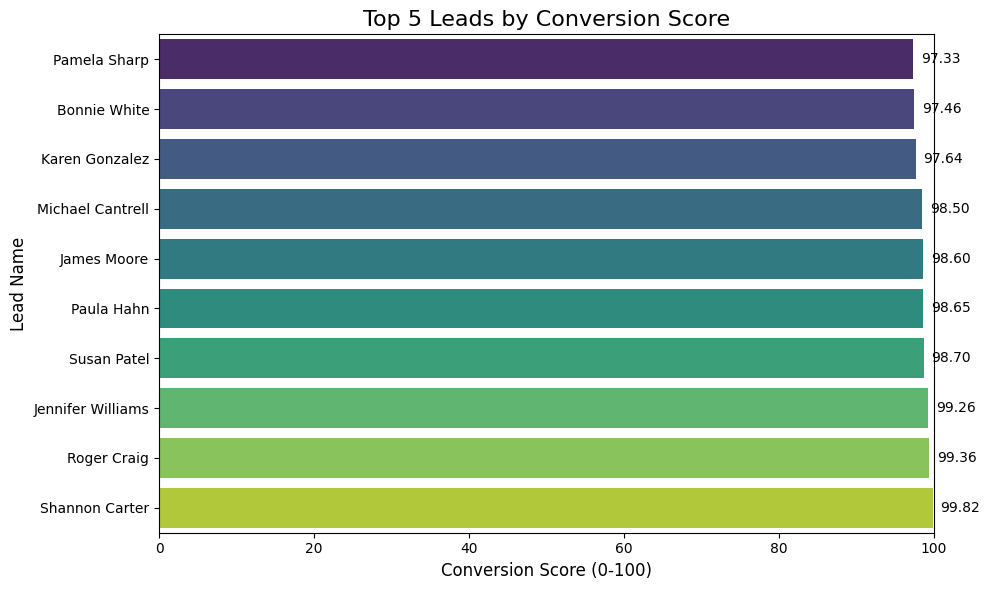

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load top 5 leads from CSV (optional, if already in variable you can skip this)
top_10 = pd.read_csv("top_10_leads_sigmoid.csv")
top_10= top_10[top_10['converted']==1]
# Sort just to be safe
top_10 = top_10.sort_values(by='conversion_score', ascending=True)  # ascending for horizontal bar chart

# Plotting
plt.figure(figsize=(10, 6))
ax=sns.barplot(
    x='conversion_score',
    y='name',
    data=top_10,
    palette='viridis'
)
#creating the bar chart for the top 10 leads based on their conversion scores and converted status=1
# Annotate bars with values
for i in ax.patches:
    score = i.get_width()
    ax.text(score + 1,                 # X position (slightly to the right of the bar)
            i.get_y() + i.get_height()/2,  # Y position (center of the bar)
            f'{score:.2f}',            # Format score
            ha='left', va='center', fontsize=10)

# Titles and labels
plt.title('Top 5 Leads by Conversion Score', fontsize=16)
plt.xlabel('Conversion Score (0-100)', fontsize=12)
plt.ylabel('Lead Name', fontsize=12)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()
# creatinfg a bar plot for the first 10 leads